# 04_explore_expanded_database

#### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

#### Import df_exact_with_dhw_and_max database

In [ ]:
# Go up one level from notebooks/ to 01_data_assembly/
root = Path("..")
file_path_import = root / "data" / "intermediate" / "df_exact_with_dhw_and_max.xlsx"
df_exact = pd.read_excel(file_path_import)

#### Missing Data and Severity Code Summary

In [6]:
mask_nan_bleached = df_exact['%_BLEACHED'].isna()
mask_nan_severity = df_exact['SEVERITY_CODE'].isna()
mask_severity_minus1 = df_exact['SEVERITY_CODE'] == -1

total_rows = len(df_exact)

pct_nan_bleached = 100 * mask_nan_bleached.sum() / total_rows

pct_nan_severity = 100 * mask_nan_severity.sum() / total_rows

mask_has_severity = df_exact['SEVERITY_CODE'].notna()
pct_minus1_given_severity = (
    100 * (mask_severity_minus1).sum() / mask_has_severity.sum()
)


print(f"total rows in database: {total_rows}")
print(f"% NaN in %_BLEACHED (whole dataset): {pct_nan_bleached:.2f}%")
print(f"% NaN in SEVERITY_CODE (whole dataset): {pct_nan_severity:.2f}%")
print(f"% SEVERITY_CODE = -1 (given SEVERITY_CODE exists): {pct_minus1_given_severity:.2f}%")

total rows in database: 21008
% NaN in %_BLEACHED (whole dataset): 17.71%
% NaN in SEVERITY_CODE (whole dataset): 0.00%
% SEVERITY_CODE = -1 (given SEVERITY_CODE exists): 1.72%


#### Severity Distribution When DHW = 0
This helps assess whether bleaching occurs outside of heat stress conditions and how it varies over time.

In [8]:
df_zero_dhw = df_exact[df_exact['DHW'] == 0].copy()

print(f"Total number of entries with DHW = 0: {len(df_zero_dhw)}\n")

def categorize_timing(days):
    if days < 0:
        return 'Before Heatwave'
    elif days > 0:
        return 'After Heatwave'
    else:
        return 'No Heatwave'

df_zero_dhw['Timing'] = df_zero_dhw['DAYS_FROM_MAX_DHW'].apply(categorize_timing)

pivot_table = pd.pivot_table(
    df_zero_dhw,
    index='SEVERITY_CODE',
    columns='Timing',
    values='FID',
    aggfunc='count',
    fill_value=0
).reindex(index=[-1, 0, 1, 2, 3], columns=['Before Heatwave', 'After Heatwave', 'No Heatwave'])

print("Distribution of SEVERITY_CODE for DHW = 0 across timing categories:")
print(pivot_table)

Total number of entries with DHW = 0: 9491

Distribution of SEVERITY_CODE for DHW = 0 across timing categories:
Timing         Before Heatwave  After Heatwave  No Heatwave
SEVERITY_CODE                                              
-1                          31              39           13
 0                        2317            1332         1754
 1                         947             567          798
 2                         622             277          395
 3                          87             120          192


- 19% of bleaching reports with DHW = 0 and SEVERITY_CODE $ \ne $ 0

##### **Subset of DF_EXACT without reports with DHW = 0 & SEVERITY_CODE 1, 2, or 3 (and SEVERITY_CODE NOT -1, LOCATION not NA)**

In [10]:
# Apply filters
df_filtered = df_exact[
    ~((df_exact['DHW'] == 0) & (df_exact['SEVERITY_CODE'].isin([1, 2, 3])))  # exclude DHW=0 + mild/mod/severe
    & (df_exact['SEVERITY_CODE'] != -1)                                      # exclude invalid severity codes                                       # exclude missing locations
].copy()

# Create DHW intervals
bins = [0, 2, 4, 6, 8, 10, np.inf]
labels = ["0–2", "2–4", "4–6", "6–8", "8–10", ">10"]

df_filtered['DHW_interval'] = pd.cut(
    df_filtered['DHW'],
    bins=bins,
    labels=labels,
    right=False
)

# Create DAYS_FROM_MAX_DHW timing groups
df_filtered['DAYS_FROM_MAX_DHW_group'] = np.select(
    [
        df_filtered['DAYS_FROM_MAX_DHW'] <= 0,
        df_filtered['DAYS_FROM_MAX_DHW'] >= 0
    ],
    [
        '≤ 0 days from max DHW',
        '≥ 0 days from max DHW'
    ],
    default='Missing DAYS_FROM_MAX_DHW'
)

# Print how many rows remain
n_rows = len(df_filtered)
print(f"Number of rows after filtering: {n_rows:,}")

# Compute distributions
dist_year = df_filtered.groupby('YEAR', dropna=False).size().reset_index(name='count')

dist_region = df_filtered.groupby('OCEAN_REGION', dropna=False).size().reset_index(name='count')

dist_severity = df_filtered.groupby('SEVERITY_CODE', dropna=False).size().reset_index(name='count')

dist_dhw = df_filtered.groupby('DHW_interval', dropna=False).size().reset_index(name='count')

dist_days_from_max_dhw = (
    df_filtered
    .groupby('DAYS_FROM_MAX_DHW_group', dropna=False)
    .size()
    .reset_index(name='count')
)

# Add percentages
for dist_df in [
    dist_year,
    dist_region,
    dist_severity,
    dist_dhw,
    dist_days_from_max_dhw
]:
    dist_df['percentage'] = dist_df['count'] / dist_df['count'].sum() * 100

# Display results
print("\nDistribution by YEAR:")
print(dist_year)

print("\nDistribution by OCEAN_REGION:")
print(dist_region)

print("\nDistribution by SEVERITY_CODE:")
print(dist_severity)

print("\nDistribution by DHW interval:")
print(dist_dhw)

print("\nDistribution by DAYS_FROM_MAX_DHW group:")
print(dist_days_from_max_dhw)

Number of rows after filtering: 16,641

Distribution by YEAR:
    YEAR  count  percentage
0   1993      1    0.006009
1   1994      1    0.006009
2   1995      1    0.006009
3   1999      1    0.006009
4   2000      1    0.006009
5   2002      3    0.018028
6   2003      3    0.018028
7   2004      7    0.042065
8   2005    171    1.027582
9   2006     72    0.432666
10  2007    172    1.033592
11  2008    166    0.997536
12  2009    322    1.934980
13  2010    558    3.353164
14  2011    303    1.820804
15  2012    179    1.075657
16  2013    236    1.418184
17  2014   3286   19.746409
18  2015   2820   16.946097
19  2016   5526   33.207139
20  2017   2812   16.898023

Distribution by OCEAN_REGION:
       OCEAN_REGION  count  percentage
0         Caribbean   5879   35.328406
1      Indian Ocean   1896   11.393546
2  NA Pacific Ocean     51    0.306472
3     Pacific Ocean   8793   52.839373
4               NaN     22    0.132204

Distribution by SEVERITY_CODE:
   SEVERITY_CODE  count  

C:\Users\Virginie\AppData\Local\Temp\ipykernel_17072\772859693.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_dhw = df_filtered.groupby('DHW_interval', dropna=False).size().reset_index(name='count')


#### Hexbin Plot of Bleaching Events with Marginal Distributions
This figure visualizes the relationship between the **timing of peak thermal stress** and the **intensity gap in Degree Heating Weeks (DHW)** for selected bleaching reports.

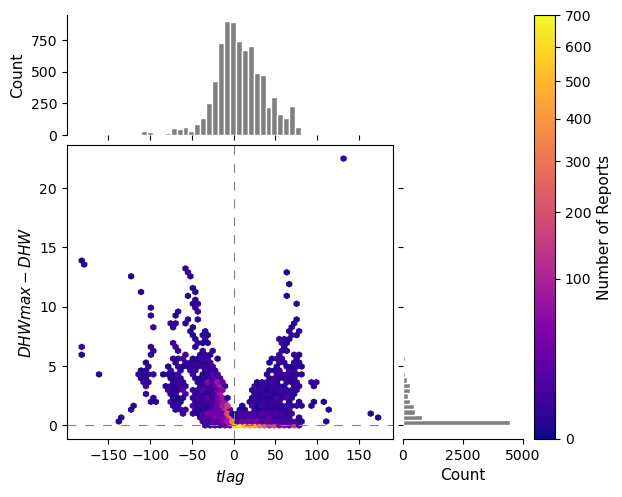

In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

df_plot = df_exact[
    (df_exact['DHW'] >= 0.5) & (df_exact['IS_BEST_REPORT'] == True)
].dropna(subset=['DHW', 'MAX_ANNUAL_DHW', 'DAYS_FROM_MAX_DHW']).copy()

df_plot['DHW_DIFF'] = df_plot['MAX_ANNUAL_DHW'] - df_plot['DHW']
x = df_plot['DAYS_FROM_MAX_DHW']
y = df_plot['DHW_DIFF']

temp_fig, temp_ax = plt.subplots()
hb_temp = temp_ax.hexbin(x, y, gridsize=60, cmap='plasma', mincnt=1)
max_count = int(np.ceil(hb_temp.get_array().max() / 100.0) * 100)
plt.close(temp_fig)

fig, main_ax = plt.subplots(figsize=(10, 8))

divider = make_axes_locatable(main_ax)
x_hist = divider.append_axes("top", size=1.2, pad=0.1, sharex=main_ax)
y_hist = divider.append_axes("right", size=1.2, pad=0.1, sharey=main_ax)

norm = mcolors.PowerNorm(gamma=0.5, vmin=0, vmax=max_count)
hb = main_ax.hexbin(x, y, gridsize=60, cmap='plasma', mincnt=1, norm=norm)

cb = fig.colorbar(hb, ax=main_ax, pad=0.02)
cb.set_label('Number of Reports', fontsize=11)
cb.set_ticks(range(0, max_count + 1, 100))
cb.ax.tick_params(labelsize=10)

main_ax.axhline(
    0,
    color='gray',
    linewidth=0.8,
    linestyle=(0, (8, 8)),
    zorder=1
)
main_ax.axvline(
    0,
    color='gray',
    linewidth=0.8,
    linestyle=(0, (8, 8)),
    zorder=1
)

# Axis labels: italic, no subscripts
main_ax.set_xlabel(r"$tlag$", fontsize=11)
main_ax.set_ylabel(r"$DHWmax - DHW$", fontsize=11)
main_ax.tick_params(labelsize=10)

# Top histogram
x_hist.hist(x, bins=50, color='gray', edgecolor='white')
x_hist.set_ylabel("Count", fontsize=11)
x_hist.tick_params(axis='x', labelbottom=False, labelsize=10)
x_hist.spines['top'].set_visible(False)
x_hist.spines['right'].set_visible(False)

# Right histogram
y_hist.hist(y, bins=50, orientation='horizontal', color='gray', edgecolor='white')
y_hist.set_xlabel("Count", fontsize=11)
y_hist.tick_params(axis='y', labelleft=False, labelsize=10)
y_hist.spines['top'].set_visible(False)
y_hist.spines['right'].set_visible(False)


# Set robust ticks based on actual histogram counts
counts, _ = np.histogram(y, bins=50)
max_y_count = int(np.ceil(counts.max() / 1000) * 1000)
y_hist.set_xticks([0, max_y_count // 2, max_y_count])
y_hist.set_xlim(0, max_y_count)

# Optional cleanup
x_hist.spines['bottom'].set_visible(False)
y_hist.spines['left'].set_visible(False)

# --- ensure ticks AFTER all plotting is done ---
xmin, xmax = main_ax.get_xlim()
ticks = np.arange(-150, 151, 50)
ticks = ticks[(ticks >= xmin) & (ticks <= xmax)]
main_ax.set_xticks(ticks)


fig.set_size_inches(7.09, 5.5)
plt.savefig("bleaching_hexbin_plot.png", dpi=300)

plt.show()

#### Extraction of Histogram Bin Edges and Counts

In [15]:
np.set_printoptions(suppress=True)

# Reproduce histogram bin edges and counts from the re-coded version
x_counts, x_bin_edges = np.histogram(x, bins=50)
y_counts, y_bin_edges = np.histogram(y, bins=50)

print("x_histo bin edges:", x_bin_edges)
print("x_histo counts per bin:", x_counts)

print("y_histo bin edges:", y_bin_edges)
print("y_histo counts per bin:", y_counts)

x_histo bin edges: [-182.  -174.9 -167.8 -160.7 -153.6 -146.5 -139.4 -132.3 -125.2 -118.1
 -111.  -103.9  -96.8  -89.7  -82.6  -75.5  -68.4  -61.3  -54.2  -47.1
  -40.   -32.9  -25.8  -18.7  -11.6   -4.5    2.6    9.7   16.8   23.9
   31.    38.1   45.2   52.3   59.4   66.5   73.6   80.7   87.8   94.9
  102.   109.1  116.2  123.3  130.4  137.5  144.6  151.7  158.8  165.9
  173. ]
x_histo counts per bin: [  9   0   1   0   0   0   3   0   5   3  36  26   4   1  16  60  45  66
  34  88 132 252 427 721 898 892 737 671 702 491 477 223 303 163 132 231
  65   2   1  11   2   1   0   0   3   0   0   0   0   2]
y_histo bin edges: [ 0.      0.4492  0.8984  1.3476  1.7968  2.246   2.6952  3.1444  3.5936
  4.0428  4.492   4.9412  5.3904  5.8396  6.2888  6.738   7.1872  7.6364
  8.0856  8.5348  8.984   9.4332  9.8824 10.3316 10.7808 11.23   11.6792
 12.1284 12.5776 13.0268 13.476  13.9252 14.3744 14.8236 15.2728 15.722
 16.1712 16.6204 17.0696 17.5188 17.968  18.4172 18.8664 19.3156 19.7648
 20.21